In [1]:
from astropy.table import Table
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import colors
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl

In [ ]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
gaiaids = pl.read_parquet('(#path to#)/allgaiadata.parq').to_pandas()
gidssmol = gaiaids[['asas_sn_id', 'gaia_id']]
del gaiaids

In [ ]:
allpred = pd.read_csv('(#path to#)/0fullpred.csv', header=None, names=['asas_sn_id', 'period', 'sigma'])

In [ ]:
predcitionsandgaia = pd.merge(gidssmol, allpred, on='asas_sn_id', how='inner').drop_duplicates(subset=['asas_sn_id'])

In [ ]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'gaia_id'})

In [ ]:
gaiatotic = pd.merge(idmatcher, predcitionsandgaia, on='gaia_id', how='inner')
del predcitionsandgaia, idmatcher, idmatch

In [ ]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('iles/crossmatch/santos2.txt', format="ascii.cds").to_pandas()
santostot = pd.concat([santos1, santos2])

In [69]:
santosmatch = pd.merge(santostot, gaiatotic, on='KIC', how='inner')
santosmatch['frac_err'] =  santosmatch['sigma']/santosmatch['period']
santosmatch['diff'] = np.abs((santosmatch['period']-santosmatch['Prot'])) / santosmatch['Prot']


In [80]:
fullsantos, fullsantosbins = np.histogram(santosmatch['frac_err'], bins=250,range=[0,15])
santos50 = santosmatch[santosmatch['diff']< 0.5]
santos20 = santosmatch[santosmatch['diff']< 0.2]
santos10 = santosmatch[santosmatch['diff']< 0.1]
santos1p = santosmatch[santosmatch['diff']< 0.01]

santoswithin50, santoswithin50bins = np.histogram(santos50['frac_err'], bins=250,range=[0,15])
santoswithin20, santoswithin20bins = np.histogram(santos20['frac_err'], bins=250,range=[0,15])
santoswithin10, santoswithin10bins = np.histogram(santos10['frac_err'], bins=250,range=[0,15])
santoswithin1, santoswithin1bins = np.histogram(santos1p['frac_err'], bins=250,range=[0,15])

detfrac_santos50 = santoswithin50/fullsantos
detfrac_santos20 = santoswithin20/fullsantos
detfrac_santos10 = santoswithin10/fullsantos
detfrac_santos1 = santoswithin1/fullsantos

detfrac_santos50_t = np.append(detfrac_santos50, 0)
detfrac_santos20_t = np.append(detfrac_santos20, 0)
detfrac_santos10_t = np.append(detfrac_santos10, 0)
detfrac_santos1_t = np.append(detfrac_santos1, 0)

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_48153/4121597067.py:12: RuntimeWarning: invalid value encountered in divide
  detfrac_santos50 = santoswithin50/fullsantos
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_48153/4121597067.py:13: RuntimeWarning: invalid value encountered in divide
  detfrac_santos20 = santoswithin20/fullsantos
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_48153/4121597067.py:14: RuntimeWarning: invalid value encountered in divide
  detfrac_santos10 = santoswithin10/fullsantos
/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_48153/4121597067.py:15: RuntimeWarning: invalid value encountered in divide
  detfrac_santos1 = santoswithin1/fullsantos


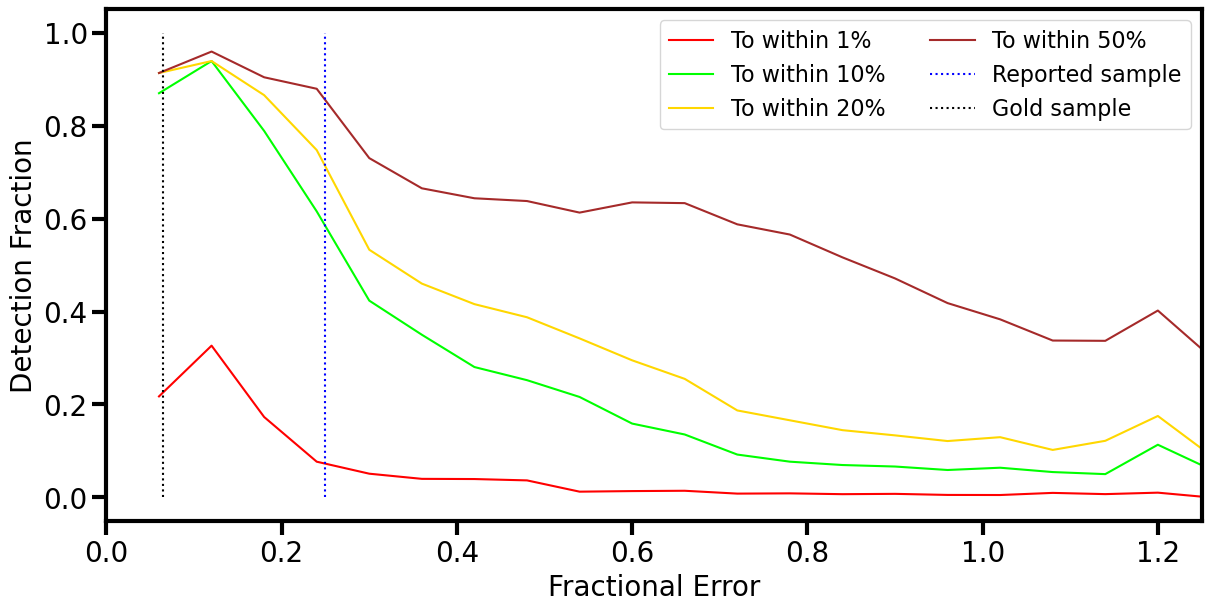

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), layout='compressed')
ax.plot(santoswithin50bins, detfrac_santos1_t, color='r', label='To within 1%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_santos10_t, color='lime', label='To within 10%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_santos20_t, color='gold', label='To within 20%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_santos50_t, color='brown', label='To within 50%', rasterized=True)

ax.set_xlabel('Fractional Error')
ax.set_ylabel('Detection Fraction')
ax.plot([0.25, 0.25], [0, 1], 'b:',label= 'Reported sample', rasterized=True)
ax.plot([0.065, 0.065], [0, 1], 'k:',label= 'Gold sample', rasterized=True)
ax.legend(ncols=2, fontsize=16)
plt.xlim(0, 1.25)
plt.savefig('santos_uplot.pdf', dpi=300)

In [ ]:

sim_input_log6 = "files/testing_csvs_section5/simulation_input_30_log6.csv"
cnn_periodsl6 = pd.read_csv(sim_input_log6, header=0, index_col="simulation_number").sort_index().rename(columns={'period':'true_period'})
cnn_periodsl6.index.names = ['sim_id']
cnn_periods_test_log6 = cnn_periodsl6[900000:]
table3_row1 = pd.read_csv("files/testing_csvs_section5/6_clump_nor_norm_nan_all/asassn_clump_0_predictions.csv", header=0).sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row1['frac_err'] = table3_row1['sigma']/table3_row1['period']
table3_row1['diff'] = np.abs(table3_row1['period']- table3_row1['true_period'])/table3_row1['true_period']

In [93]:
fulltraininghist, fulltraininghistbins =  np.histogram(table3_row1, bins=250,range=[0,15])

In [95]:
pred50 =table3_row1[table3_row1['diff']<0.5]
pred20 = table3_row1[table3_row1['diff']<0.2]
pred10 = table3_row1[table3_row1['diff']<0.1]
pred1 = table3_row1[table3_row1['diff']<0.01]

predswithin50, predswithin50bins = np.histogram(pred50['frac_err'], bins=250,range=[0,15])
predswithin20, predswithin20bins = np.histogram(pred20['frac_err'], bins=250,range=[0,15])
predswithin10, predswithin10bins = np.histogram(pred10['frac_err'], bins=250,range=[0,15])
predswithin1, predswithin1bins = np.histogram(pred1['frac_err'], bins=250,range=[0,15])

detfrac_preds50 = predswithin50/fulltraininghist
detfrac_preds20 = predswithin20/fulltraininghist
detfrac_preds10 = predswithin10/fulltraininghist
detfrac_preds1 = predswithin1/fulltraininghist

detfrac_preds50_t = np.append(detfrac_preds50, 0)
detfrac_preds20_t = np.append(detfrac_preds20, 0)
detfrac_preds10_t = np.append(detfrac_preds10, 0)
detfrac_preds1_t = np.append(detfrac_preds1, 0)

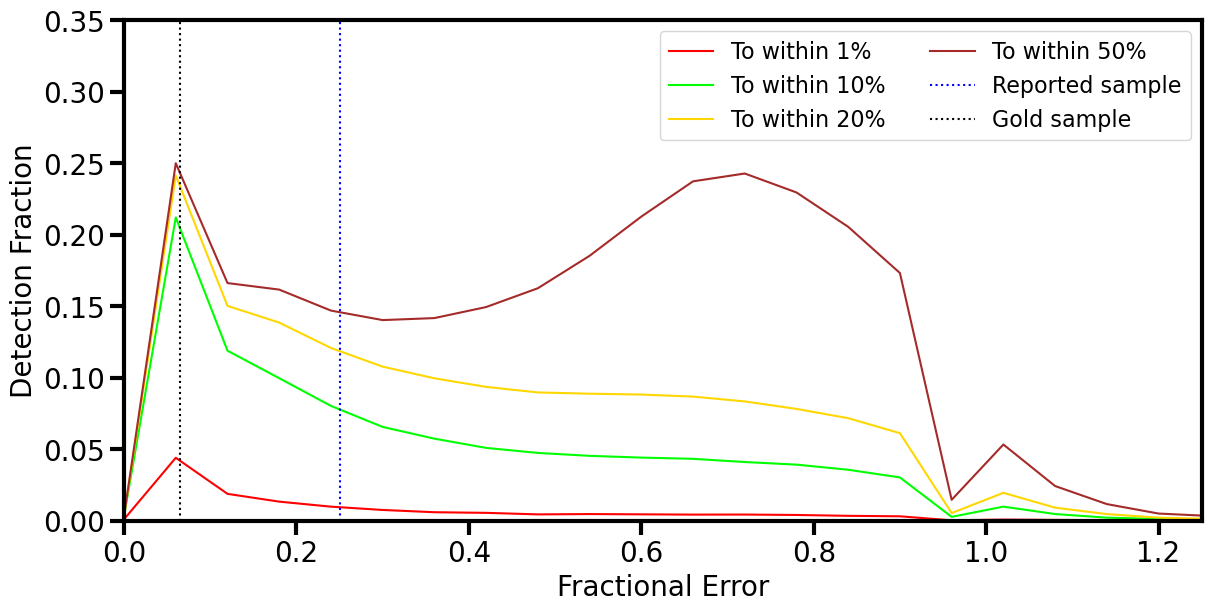

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), layout='compressed')
ax.plot(santoswithin50bins, detfrac_preds1_t, color='r', label='To within 1%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_preds10_t, color='lime', label='To within 10%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_preds20_t, color='gold', label='To within 20%', rasterized=True)
ax.plot(santoswithin50bins, detfrac_preds50_t, color='brown', label='To within 50%', rasterized=True)

ax.set_xlabel('Fractional Error')
ax.set_ylabel('Detection Fraction')
ax.plot([0.25, 0.25], [0, 1], 'b:',label= 'Reported sample', rasterized=True)
ax.plot([0.065, 0.065], [0, 1], 'k:',label= 'Gold sample', rasterized=True)
ax.legend(ncols=2, fontsize=16)
plt.xlim(0, 1.25)
plt.ylim(0, 0.35)
plt.savefig('predictions_uplot.pdf', dpi=300)